<h3> Method with weighted means for finding the centeroid embedding of a document and Hierachical clustering. </h3>

<h5> Imports </h5>

In [2]:
import json
import glob
import os

import numpy as np

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from kneed import KneeLocator

import shutil

<h5> To avoid the re-embedding from scratch, we just pick-up the embedding results from the files </h5>

In [3]:
# Read all JSON files from embeddings folder
embeddings_dir = os.path.join("data_output", "embeddings")
files_dir = "data"
embeddings_files = glob.glob(os.path.join(embeddings_dir, "*.json"))

all_results = []

print(f"Found {len(embeddings_files)} JSON files in {embeddings_dir}")

for json_file in embeddings_files:
    try:
        with open(json_file, "r", encoding="utf-8") as f:
            doc_data = json.load(f)
            all_results.append(doc_data)
        print(f"Loaded: {os.path.basename(json_file)}")
    except Exception as e:
        print(f"Error loading {json_file}: {e}")

print(f"Total documents loaded: {len(all_results)}")

Found 1068 JSON files in data_output/embeddings
Loaded: Fortimo_LED_Strip_5ft_MF_9xx_LV6_embeddings.json
Loaded: dig-sr-connector_embeddings.json
Loaded: Fortimo_LED_Strip_0.25ft_MF_9xx_HV6_x_2pcs_embeddings.json
Loaded: 202308-1-design-in-guide-led-indoor-driver-spot-downlight_embeddings.json
Loaded: SIG-Xitanium-SR-Bridge-DIG-A11_embeddings.json
Loaded: Datasheet_LED_Transformer_75W_24VDC_120-277V_IP67_929003413906_embeddings.json
Loaded: Fortimo-LED-Square-1250lm-9xx-HV-LV3_embeddings.json
Loaded: Fortimo_LED_Strip_CED_1ft_MF_FC_LV5__embeddings.json
Loaded: Fortimo-LED-Strip-PR-FT-2ft-2200lm-927-965-FC-HV5_embeddings.json
Loaded: Datasheet-Fortimo-1100-lm_embeddings.json
Loaded: Fortimo_LED_Line_1ft_MF_8xx_1R_LV5__embeddings.json
Loaded: LED_Transformer_120W_24VDC_913710032567_embeddings.json
Loaded: Fortimo_SLM_C_1201_L09_1313_G7N_HE_plus__embeddings.json
Loaded: Fortimo_LED_Strip_2ft_2200lm_9xx_LV4__embeddings.json
Loaded: Fortimo_FastFlex_2x6_DA_G4plus_embeddings.json
Loaded: Xit

<h5> Compute a weighted mean from individual chunks (page embeddings) for each document </h5>

In [4]:
def weighted_mean_doc_vector(page_embeddings, weights=None):
    if not page_embeddings:
        return None

    V = np.vstack(page_embeddings)  # (n_pages, d)

    if weights is None:
        w = np.ones(len(V), dtype="float32")
    else:
        w = np.asarray(weights, dtype="float32")
        w = w / (w.sum() + 1e-12)

    v = (w[:, None] * V).sum(axis=0)
    v /= (np.linalg.norm(v) + 1e-12)
    return v

In [5]:
for doc_result in all_results:
    page_embeddings = doc_result.get("embeddings", [])
    page_texts = [p.get("text","") for p in doc_result.get("pages", [])]
    v_doc = weighted_mean_doc_vector(page_embeddings)
    doc_result["doc_vector"] = None if v_doc is None else v_doc.tolist()

In [6]:
import umap

X_array = np.array([doc_result["doc_vector"] for doc_result in all_results if doc_result["doc_vector"] is not None])
reducer = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    n_components=2,
    metric="cosine",
    random_state=42
)

X_2d = reducer.fit_transform(X_array)


/Volumes/BackupHD/Projects/variant-logic/vl-blogs/.venv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


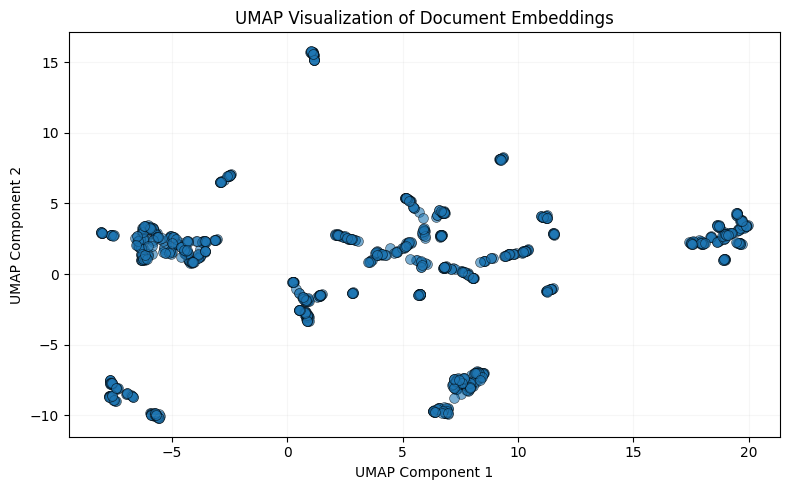

Visualized 1064 documents in 2D space
UMAP reduced dimensions from 3072 to 2


In [8]:
plt.figure(figsize=(8, 5))
plt.scatter(X_2d[:, 0], X_2d[:, 1], alpha=0.6, s=50, edgecolors='black', linewidth=0.5)
plt.title("UMAP Visualization of Document Embeddings")
plt.xlabel("UMAP Component 1")
plt.ylabel("UMAP Component 2")
plt.grid(True, alpha=0.1)
plt.tight_layout()
plt.show()

print(f"Visualized {len(X_2d)} documents in 2D space")
print(f"UMAP reduced dimensions from {X_array.shape[1]} to {X_2d.shape[1]}")

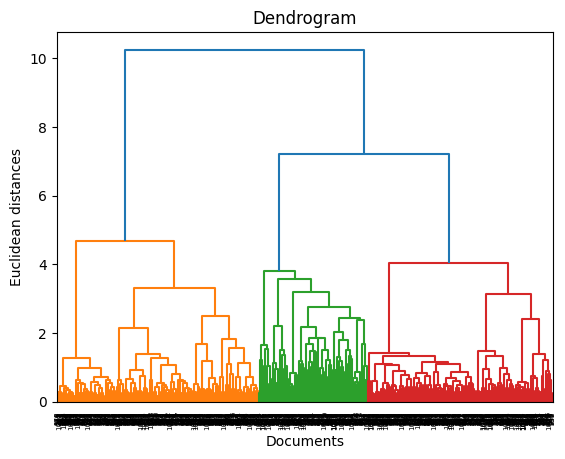

In [7]:
# Using dendrogram to find the optimal number of clusters
# We use the scipy library to create the dendrogram
# pip install scipy
import scipy.cluster.hierarchy as sch
dendrogram = sch.dendrogram(sch.linkage([doc_result["doc_vector"] for doc_result in all_results if doc_result["doc_vector"] is not None], method = 'ward'))
plt.title('Dendrogram')
plt.xlabel('Documents')
plt.ylabel('Euclidean distances')
plt.show()

In [18]:
n_clusters = 3

In [19]:
from sklearn.cluster import AgglomerativeClustering
hc = AgglomerativeClustering(n_clusters=n_clusters, linkage='ward')
X = [doc_result["doc_vector"] for doc_result in all_results if doc_result["doc_vector"] is not None]
y_hc = hc.fit_predict(X)

In [20]:
# Add cluster labels to all_results
cluster_idx = 0
for doc in all_results:
    if doc.get('doc_vector') is not None:
        doc['cluster'] = int(y_hc[cluster_idx])
        cluster_idx += 1

# Display clustering results
print(f"Clustering complete with {n_clusters} clusters")
print("\nCluster distribution:")
for i in range(n_clusters):
    count = np.sum(y_hc == i)
    print(f"Cluster {i}: {count} documents")

# Show sample documents from each cluster
print("\nSample documents per cluster:")
for i in range(n_clusters):
    cluster_docs = [os.path.basename(doc['file']) for doc in all_results 
                   if doc.get('doc_vector') is not None and doc.get('cluster') == i]
    print(f"\nCluster {i} ({len(cluster_docs)} docs):")
    # Show first 5 documents
    for doc in cluster_docs[:5]:
        print(f"  - {doc}")
    if len(cluster_docs) > 5:
        print(f"  ... and {len(cluster_docs) - 5} more")

Clustering complete with 3 clusters

Cluster distribution:
Cluster 0: 434 documents
Cluster 1: 398 documents
Cluster 2: 232 documents

Sample documents per cluster:

Cluster 0 (434 docs):
  - Fortimo_LED_Strip_5ft_MF_9xx_LV6.pdf
  - Fortimo_LED_Strip_0.25ft_MF_9xx_HV6_x_2pcs.pdf
  - Fortimo-LED-Square-1250lm-9xx-HV-LV3.pdf
  - Fortimo_LED_Strip_CED_1ft_MF_FC_LV5_.pdf
  - Fortimo-LED-Strip-PR-FT-2ft-2200lm-927-965-FC-HV5.pdf
  ... and 429 more

Cluster 1 (398 docs):
  - Datasheet_LED_Transformer_75W_24VDC_120-277V_IP67_929003413906.pdf
  - LED_Transformer_120W_24VDC_913710032567.pdf
  - Xitanium_30W_a_0.6_0.75A_40V_3CW_230V_929002103606.pdf
  - Xitanium-50W_WH_0.7-1.5A_54V_SR_Is_230V_929002861306.pdf
  - CertaDrive_30W_0.29A_102V_230V_929001598606.pdf
  ... and 393 more

Cluster 2 (232 docs):
  - dig-sr-connector.pdf
  - 202308-1-design-in-guide-led-indoor-driver-spot-downlight.pdf
  - SIG-Xitanium-SR-Bridge-DIG-A11.pdf
  - Datasheet-Fortimo-1100-lm.pdf
  - InteGrade-S-commercial-leafle

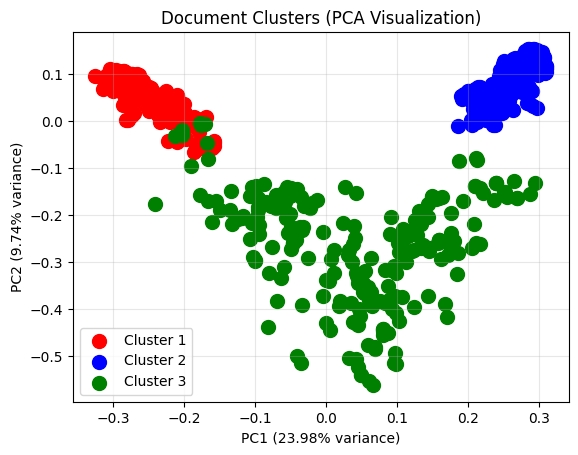

Cluster 1: 434 documents
Cluster 2: 398 documents
Cluster 3: 232 documents


In [21]:
# Convert X to numpy array and apply dimensionality reduction for visualization
from sklearn.decomposition import PCA

X_array = np.array(X)
pca = PCA(n_components=2)
X_2d = pca.fit_transform(X_array)

# Plot clusters
colors = ['red', 'blue', 'green', 'cyan', 'magenta', 'yellow', 'black', 'orange']
for i in range(n_clusters):
    mask = y_hc == i
    plt.scatter(X_2d[mask, 0], X_2d[mask, 1], s=100, c=colors[i], label=f'Cluster {i+1}')

plt.title('Document Clusters (PCA Visualization)')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%} variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%} variance)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Print cluster information
for i in range(3):
    count = np.sum(y_hc == i)
    print(f"Cluster {i+1}: {count} documents")

In [22]:
# Create main clusters folder
clusters_main_dir = os.path.join("data_output", "clusters-07")
os.makedirs(clusters_main_dir, exist_ok=True)

# Create subfolders for each cluster and copy files
for cluster_id in range(n_clusters):
    # Create cluster subfolder
    cluster_dir = os.path.join(clusters_main_dir, f"cluster{cluster_id}")
    os.makedirs(cluster_dir, exist_ok=True)
    
    # Get documents in this cluster
    cluster_doc_count = 0
    for doc in all_results:
        if doc.get('cluster') == cluster_id:
            # Get original filename for destination
            original_filename = os.path.basename(doc['file'])
            
            # Source file path (use the full path from doc['file'])
            source_file = doc['file']
            
            # Destination file path
            dest_file = os.path.join(cluster_dir, original_filename)
            
            # Copy file to cluster folder
            if os.path.exists(source_file):
                shutil.copy2(source_file, dest_file)
                cluster_doc_count += 1
            else:
                print(f"Warning: File not found: {source_file}")
    
    print(f"Cluster {cluster_id}: {cluster_doc_count} files copied to {cluster_dir}")

print(f"All files organized into {clusters_main_dir}")

Cluster 0: 434 files copied to data_output/clusters-07/cluster0
Cluster 1: 398 files copied to data_output/clusters-07/cluster1
Cluster 2: 232 files copied to data_output/clusters-07/cluster2
All files organized into data_output/clusters-07
